# Transfer Learning for Binary Forest Segmentation
U-Net with ResNet50 encoder: training from scratch vs. transfer learning (ImageNet).

## 1. Imports

In [2]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"

import time
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import segmentation_models as sm
from sklearn.model_selection import train_test_split

2026-09-28 07:57:21.530688: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-28 07:57:21.703968: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-28 07:57:21.704006: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-28 07:57:21.730335: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-28 07:57:21.787096: I tensorflow/core/platform/cpu_feature_guar

Segmentation Models: using `tf.keras` framework.


In [4]:
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.15.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-09-28 07:57:38.118653: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-28 07:57:38.283770: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-28 07:57:38.285552: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

## 2. Configuration
Choices: 128×128 input, pixels normalized to [0, 1], 70/15/15 split, BCE + Dice loss, Adam optimizer.

In [5]:
BASE = "archive/Forest Segmented"

SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 100
LR = 1e-4            # main learning rate
LR_FINETUNE = 1e-5   # lower LR for fine-tuning the unfrozen encoder

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

## 3. Loading dataset

In [6]:
def load_sample(img_name, mask_name):
    img = cv2.imread(f"{BASE}/images/{img_name}")
    # OpenCV default is (Blue, Green, Red) but libraries expect (Red, Green, Blue)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
    # Making sure that image sizes are consistent and pixel values are normalized (0-1 range)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    mask = cv2.imread(f"{BASE}/masks/{mask_name}", cv2.IMREAD_GRAYSCALE)  # loading mask as grey scale image (1 channel)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)  # resizing image 
    mask = (mask > 127).astype("float32")[..., None]    # adds channel dimension

    return img.astype("float32"), mask


meta = pd.read_csv(f"{BASE}/meta_data.csv")

X, Y = [], []
for img_name, mask_name in zip(meta["image"], meta["mask"]):
    img, mask = load_sample(img_name, mask_name)
    X.append(img)
    Y.append(mask)

X, Y = np.array(X), np.array(Y)

# 4. Train Test Split

In [8]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, 
    Y, 
    test_size=0.3, 
    random_state=SEED
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, 
    Y_temp, 
    test_size=0.5, 
    random_state=SEED
)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train: (3575, 128, 128, 3) | Val: (766, 128, 128, 3) | Test: (767, 128, 128, 3)


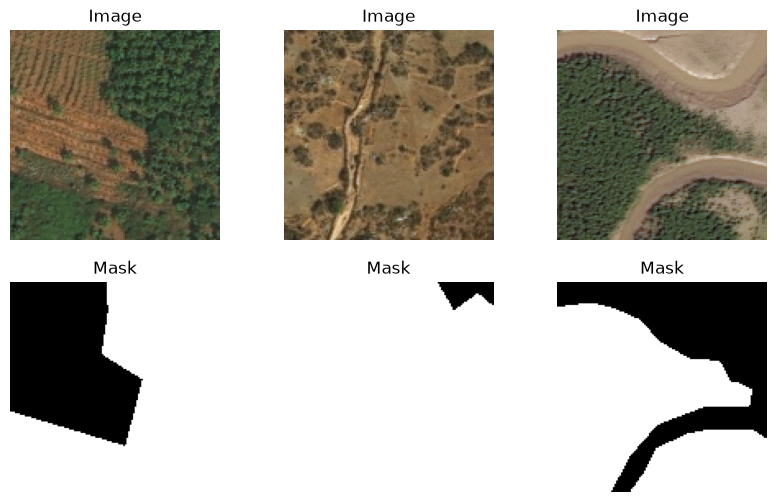

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for i in range(3):
    axes[0, i].imshow(X_train[i]);                  axes[0, i].set_title("Image")
    axes[1, i].imshow(Y_train[i, ..., 0], cmap="gray"); axes[1, i].set_title("Mask")
for ax in axes.ravel():
    ax.axis("off")
plt.show()

## 4. Loss, metrics and helpers

In [10]:
LOSS = sm.losses.BinaryCELoss() + sm.losses.DiceLoss()
METRICS = [sm.metrics.IOUScore(threshold=0.5), sm.metrics.FScore(threshold=0.5)]


# encoder_weights: initial weights, if None means start with random weights
# freeze_encoder: True means encoder is trainable, False means encoder's training won't happen
# classes: How many channels of output. 
# activation: sigmoid means output is probability of foreground and background
def build_unet(encoder_weights, freeze_encoder=False):
    return sm.Unet(
        "resnet50",
        encoder_weights=encoder_weights,
        encoder_freeze=freeze_encoder,
        classes=1,
        activation="sigmoid",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )


def compile_model(model, lr):
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=LOSS, metrics=METRICS)


def train(model, epochs, initial_epoch=0):
    return model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=epochs,
        initial_epoch=initial_epoch,
        batch_size=BATCH_SIZE,
    )


def count_trainable(model):
    return int(sum(np.prod(w.shape) for w in model.trainable_weights))

## 5. Experiment 1 — Training from scratch (100 epochs)

In [11]:
scratch_model = build_unet(encoder_weights=None)
compile_model(scratch_model, LR)
print("Trainable params:", count_trainable(scratch_model))

start = time.time()
hist_scratch = train(scratch_model, EPOCHS)
time_scratch = time.time() - start

scratch_model.save_weights("scratch_model.h5")
print(f"Training time: {time_scratch / 60:.1f} min")

2026-09-28 07:58:04.278161: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-28 07:58:04.280658: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-28 07:58:04.282257: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Trainable params: 32513556
Epoch 1/100


2026-09-28 07:58:13.338632: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-09-28 07:58:13.560624: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-09-28 07:58:13.918767: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-09-28 07:58:18.571412: I external/local_xla/xla/service/service.cc:168] XLA service 0x77a1e2429ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-28 07:58:18.571445: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-09-28 07:58:18.590871: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790564298.684509    8145 devic

224/224 [==============================] - 62s 146ms/step - loss: 0.8085 - iou_score: 0.6728 - f1-score: 0.8023 - val_loss: 2.9456 - val_iou_score: 6.2776e-04 - val_f1-score: 0.0013
Epoch 2/100
224/224 [==============================] - 18s 81ms/step - loss: 0.7054 - iou_score: 0.7155 - f1-score: 0.8324 - val_loss: 1.1409 - val_iou_score: 0.5260 - val_f1-score: 0.6828
Epoch 3/100
224/224 [==============================] - 18s 81ms/step - loss: 0.6861 - iou_score: 0.7240 - f1-score: 0.8379 - val_loss: 0.6756 - val_iou_score: 0.7095 - val_f1-score: 0.8280
Epoch 4/100
224/224 [==============================] - 18s 81ms/step - loss: 0.6564 - iou_score: 0.7363 - f1-score: 0.8466 - val_loss: 0.6790 - val_iou_score: 0.7245 - val_f1-score: 0.8386
Epoch 5/100
224/224 [==============================] - 18s 81ms/step - loss: 0.6372 - iou_score: 0.7428 - f1-score: 0.8507 - val_loss: 0.6951 - val_iou_score: 0.7051 - val_f1-score: 0.8253
Epoch 6/100
224/224 [==============================] - 18s 82m

## 6. Experiment 2 — Transfer learning (50 frozen + 50 fine-tuning)

In [12]:
tl_model = build_unet(encoder_weights="imagenet", freeze_encoder=True)

# Phase 1: encoder frozen, train decoder only
compile_model(tl_model, LR)
print("Phase 1 trainable params:", count_trainable(tl_model))

start = time.time()
hist_phase1 = train(tl_model, epochs=EPOCHS // 2)

# Phase 2: unfreeze everything, fine-tune with a lower learning rate
for layer in tl_model.layers:
    layer.trainable = True
compile_model(tl_model, LR_FINETUNE)   # recompile is required after changing trainable
print("Phase 2 trainable params:", count_trainable(tl_model))

hist_phase2 = train(tl_model, epochs=EPOCHS, initial_epoch=EPOCHS // 2)
time_tl = time.time() - start

tl_model.save_weights("transfer_model.h5")
print(f"Training time: {time_tl / 60:.1f} min")

Phase 1 trainable params: 9058644
Epoch 1/50
224/224 [==============================] - 27s 73ms/step - loss: 0.8147 - iou_score: 0.6728 - f1-score: 0.7998 - val_loss: 5.2325 - val_iou_score: 6.0134e-04 - val_f1-score: 0.0012
Epoch 2/50
224/224 [==============================] - 16s 70ms/step - loss: 0.6657 - iou_score: 0.7300 - f1-score: 0.8423 - val_loss: 6.8013 - val_iou_score: 2.8732e-04 - val_f1-score: 5.7448e-04
Epoch 3/50
224/224 [==============================] - 16s 70ms/step - loss: 0.6343 - iou_score: 0.7415 - f1-score: 0.8497 - val_loss: 6.8214 - val_iou_score: 1.1995e-04 - val_f1-score: 2.3987e-04
Epoch 4/50
224/224 [==============================] - 16s 70ms/step - loss: 0.5971 - iou_score: 0.7545 - f1-score: 0.8587 - val_loss: 3.5576 - val_iou_score: 1.8646e-04 - val_f1-score: 3.7285e-04
Epoch 5/50
224/224 [==============================] - 16s 70ms/step - loss: 0.5737 - iou_score: 0.7637 - f1-score: 0.8646 - val_loss: 0.9960 - val_iou_score: 0.5286 - val_f1-score: 0.686

## 7. Test-set evaluation

In [13]:
def evaluate(model):
    pred = model.predict(X_test, batch_size=BATCH_SIZE).ravel() > 0.5
    true = Y_test.ravel() > 0.5

    tp = np.sum(pred & true)
    fp = np.sum(pred & ~true)
    fn = np.sum(~pred & true)
    tn = np.sum(~pred & ~true)
    eps = 1e-7

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    return {
        "IoU": tp / (tp + fp + fn + eps),
        "Accuracy": (tp + tn) / (tp + tn + fp + fn),
        "Precision": precision,
        "Recall": recall,
        "F1": 2 * precision * recall / (precision + recall + eps),
    }


results = pd.DataFrame(
    [evaluate(scratch_model), evaluate(tl_model)],
    index=["Scratch", "Transfer Learning"],
)
results["Training time (min)"] = [time_scratch / 60, time_tl / 60]
results.round(4)

48/48 [==============================] - 1s 21ms/step


,IoU,Accuracy,Precision,Recall,F1,Training time (min)
Scratch,0.6837,0.7666,0.8124,0.8119,0.8121,31.1412
Transfer Learning,0.7618,0.8279,0.8451,0.8854,0.8648,28.6001


## 8. Training curves

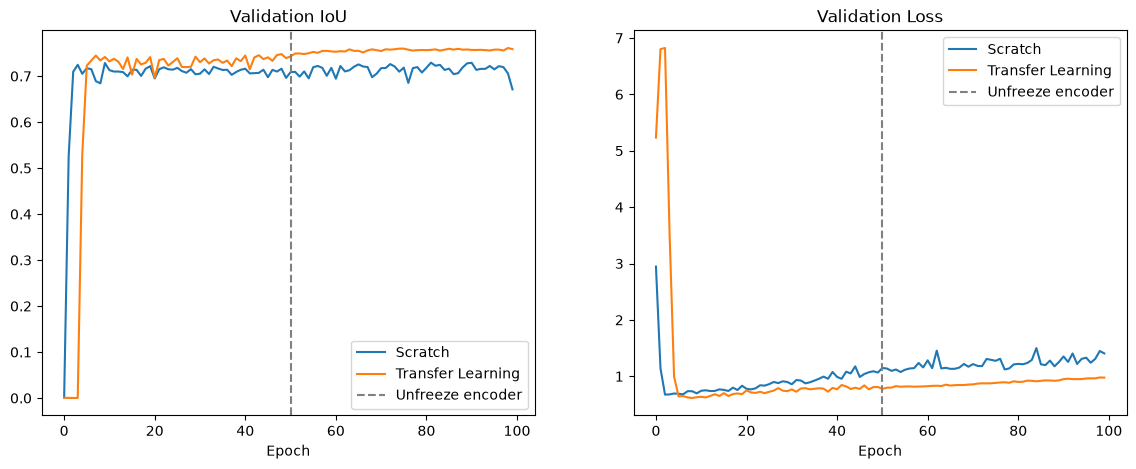

In [14]:
tl_history = {k: hist_phase1.history[k] + hist_phase2.history[k] for k in hist_phase1.history}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, key, title in [(axes[0], "val_iou_score", "Validation IoU"), (axes[1], "val_loss", "Validation Loss")]:
    ax.plot(hist_scratch.history[key], label="Scratch")
    ax.plot(tl_history[key], label="Transfer Learning")
    ax.axvline(EPOCHS // 2, color="gray", linestyle="--", label="Unfreeze encoder")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend()
plt.show()

## 9. Visual comparison

1/1 [==============================] - 0s 18ms/step


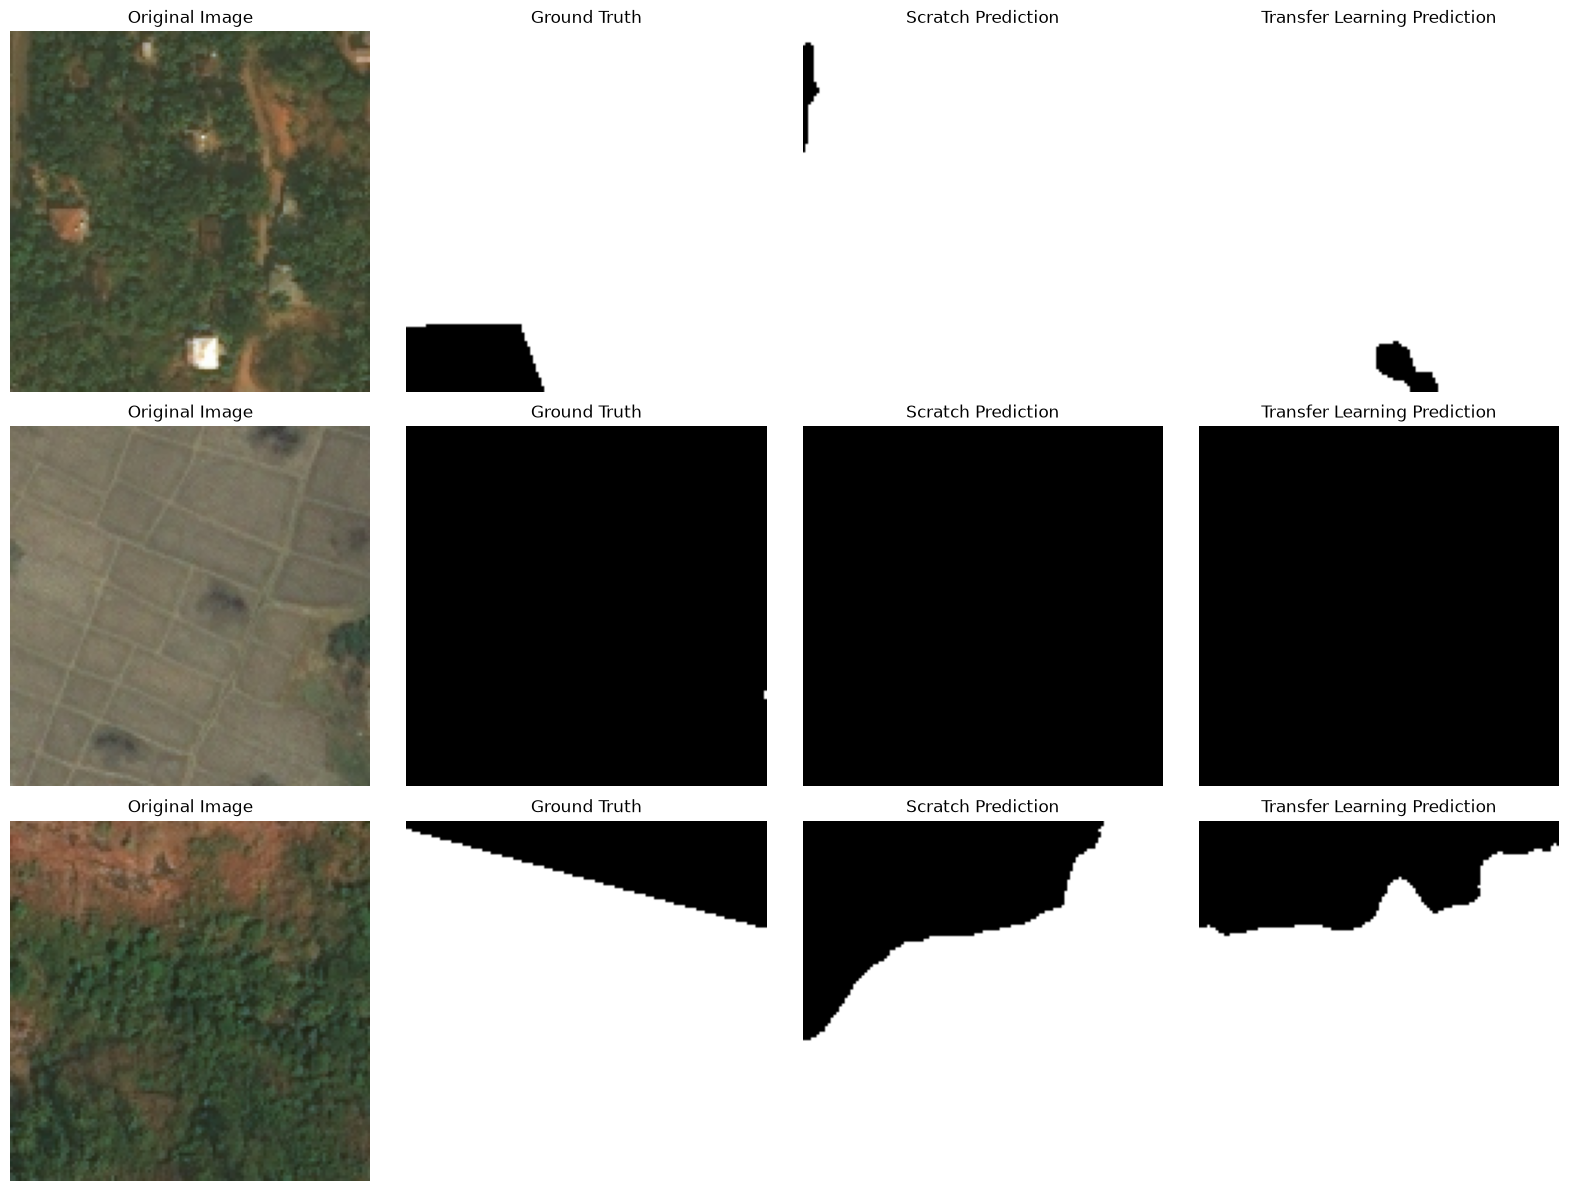

In [15]:
sample_ids = [0, 10, 20]
pred_scratch = scratch_model.predict(X_test[sample_ids]) > 0.5
pred_tl = tl_model.predict(X_test[sample_ids]) > 0.5

titles = ["Original Image", "Ground Truth", "Scratch Prediction", "Transfer Learning Prediction"]
fig, axes = plt.subplots(len(sample_ids), 4, figsize=(16, 4 * len(sample_ids)))

for row, idx in enumerate(sample_ids):
    panels = [X_test[idx], Y_test[idx, ..., 0], pred_scratch[row, ..., 0], pred_tl[row, ..., 0]]
    for col, panel in enumerate(panels):
        axes[row, col].imshow(panel, cmap=None if col == 0 else "gray")
        axes[row, col].set_title(titles[col])
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 10. Comparative Analysis

Performance: Transfer learning won in all metrices because the ImageNet-pretrained encoder already detects edges, textures and color patterns, so it converges faster and generalizes better on a moderately sized dataset.

Efficiency: Phase with transfer learning is faster per epoch because encoder gradients aren't computed. From scratch implementation took 34 minutes and transfer learning took 24 minutes.